# Testing across multiple products

## Level 3

* `short_name="ATL21"` level 3, daily and monthly gridded polar sea surface height (SSH) anomalies
* `short_name="ATL08"` level 3, land vegetation
* `collection_id = "C2237824918-ORNL_CLOUD"` level 3, above ground biomass [notebook](https://nasa-openscapes.github.io/earthdata-cloud-cookbook/tutorials/Above_Ground_Biomass_Density.html)
* `short_name="ECCO_L4_SSH_05DEG_MONTHLY_V4R4"` level 4, ECCO Sea Surface Height - Monthly Mean 0.5 Degree (Version 4 Release 4)
* `short_name="MUR-JPL-L4-GLOB-v4.1"` level 4 SST
* `short_name="MUR25-JPL-L4-GLOB-v04.2"` level 4 SST
* `short_name = "TEMPO_NO2_L3", version = "V03"` level 3 [notebook](https://nasa.github.io/ASDC_Data_and_User_Services/TEMPO/how_to_examine_TEMPO_data_using_earthaccess.html)
* `short_name = "MIL3YAEN"` level 3, global aerosol [notebook](https://nasa.github.io/ASDC_Data_and_User_Services/MISR/how_to_compute_and_visualize_aerosol_optical_depths.html)
* `short_name = "MOP03JM", version = "9"` level 3, pollution [notebook](https://nasa.github.io/ASDC_Data_and_User_Services/MOPITT/how_to_plot_carbon_monoxide_mixing_ratio.html)

## Level 2

* `collection_id = "C1962643459-LARC_ASDC"` level 2 [notebook](https://nasa.github.io/ASDC_Data_and_User_Services/DSCOVR/how_to_explore_aerosol_data_from_EPIC_and_EPA-AQS.html)
* `short_name="ATL03"` level 2, icesat-2. [notebook](https://nasa-openscapes.github.io/earthdata-cloud-cookbook/tutorials/Harmony.html)
* `short_name = "PREFIRE_SAT2_2B-CLD"` level 2 [notebook](https://nasa.github.io/ASDC_Data_and_User_Services/PREFIRE/plot_PREFIRE_L2_CLD_with_earthaccess_and_Harmony.html)
* `short_name = "DSCOVR_EPIC_L2_AER"` level 2 [notebook](https://nasa.github.io/ASDC_Data_and_User_Services/DSCOVR/how_to_compare_TEMPO_with_DSCOVR_and_AERONET_uvai.html)
* `short_name = "TEMPO_O3TOT_L2"` level 2 [notebook](https://nasa.github.io/ASDC_Data_and_User_Services/DSCOVR/how_to_compare_spatially_TEMPO_with_DSCOVR_uvai.html) [notebook](https://nasa.github.io/ASDC_Data_and_User_Services/DSCOVR/how_to_compare_TEMPO_with_DSCOVR_and_AERONET_uvai.html)
* `short_name = "DSCOVR_EPIC_L2_TO3", version = "03"` level 2 [notebook](https://nasa.github.io/ASDC_Data_and_User_Services/DSCOVR/how_to_plot_ozone_product_parameters.html)


### Special cases

* `short_name = "CAL_LID_L1-Standard-V4-51", version = "V4-51"` level 1b  Cloud-Aerosol Lidar and Infrared Pathfinder Satellite Observations (CALIPSO) [notebook](https://nasa.github.io/ASDC_Data_and_User_Services/CALIPSO/how_to_plot_ozone_number_densities.html)
* `short_name=['HLSL30','HLSS30']` Harmonized Landsat Sentinel-2 (HLS) data [notebook](https://nasa-openscapes.github.io/earthdata-cloud-cookbook/tutorials/Observing_Seasonal_Ag_Changes.html) These are tifs. Need different kind of opening.
  

## Create some points

Random global.

In [1]:
import numpy as np
import pandas as pd
# pip install global-land-mask

# inputs
n_points = 1000
start_date = "1992-01-01"
end_date = "2024-12-31"

# convert to datetime
start = pd.to_datetime(start_date)
end = pd.to_datetime(end_date)

lat = np.degrees(np.arcsin(np.random.uniform(-1, 1, n_points)))
lon = np.random.uniform(-180, 180, n_points)

# random dates
days = pd.date_range(start, end, freq="D")
time = np.random.choice(days, n_points)

# dataframe
df_points = pd.DataFrame({
    "lat": lat,
    "lon": lon,
    "time": time
})

from global_land_mask import globe

df_points["land"] = globe.is_land(df_points["lat"].values,
                                     df_points["lon"].values)

print(df_points.head())

         lat         lon       time   land
0 -73.432852   -7.705424 2013-08-26   True
1  24.189353   57.091891 2020-05-06  False
2 -18.861713  112.017740 2010-05-31  False
3  51.745064   34.896836 2012-04-10   True
4  28.666060  -68.808228 2004-08-04  False


## ICESAT-2 ATL21

This h5 grouped data files. Somewhat horribly it has monthly, daily, and metadata all crammed together.

* to do, need to be able to customize the datatree-merge step to reliably deal with level 2 files

In [10]:
import point_collocation as pc
short_name="ATL21"
df = df_points[df_points["time"].dt.year == 2024]
plan = pc.plan(
    df,
    data_source="earthaccess",
    source_kwargs={
        "short_name": short_name,
    }
)

In [45]:
import earthaccess
results = earthaccess.search_data(
    short_name="ATL21"
)
print(len(results))
f = earthaccess.open(results[0:2])

320


QUEUEING TASKS | :   0%|          | 0/2 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/2 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/2 [00:00<?, ?it/s]

In [51]:
import xarray as xr
dt = xr.open_datatree(f[1], decode_timedelta=False, phony_dims='sort')
ds = xr.merge(
    [dt["/"].ds, dt["/monthly"].ds]
)
ds = ds.set_coords(["grid_lat", "grid_lon"])
ds

<xarray.Dataset> Size: 8MB
Dimensions:                        (grid_y: 448, grid_x: 304, phony_dim_23: 1)
Coordinates:
  * grid_y                         (grid_y) float64 4kB 5.838e+06 ... -5.338e+06
  * grid_x                         (grid_x) float64 2kB -3.838e+06 ... 3.738e+06
    grid_lat                       (grid_y, grid_x) float64 1MB ...
    grid_lon                       (grid_y, grid_x) float64 1MB ...
Dimensions without coordinates: phony_dim_23
Data variables:
    crs                            int8 1B ...
    land_mask_map                  (grid_y, grid_x) float64 1MB ...
    delta_time_beg                 (phony_dim_23) datetime64[ns] 8B ...
    delta_time_end                 (phony_dim_23) datetime64[ns] 8B ...
    mean_ssha                      (grid_y, grid_x) float32 545kB ...
    mean_weighted_earth_free2mean  (grid_y, grid_x) float32 545kB ...
    mean_weighted_geoid            (grid_y, grid_x) float32 545kB ...
    mean_weighted_geoid_free2mean  (grid_y, grid_x) float32 545kB ...
    mean_weighted_mss              (grid_y, grid_x) float32 545kB ...
    n_refsurfs                     (grid_y, grid_x) float64 1MB ...
    sigma                          (grid_y, grid_x) float32 545kB ...
Attributes: (12/46)
    short_name:                         ATL21
    level:                              L3B
    description:                        This data set (ATL21) contains daily ...
    Conventions:                        CF-1.7
    contributor_name:                   Alek Petty (alek.a.petty@nasa.gov), R...
    contributor_role:                   Investigator, Investigator, Investiga...
    ...                                 ...
    processing_level:                   3B
    references:                         http://nsidc.org/data/icesat2/data.html
    project:                            ICESat-2 > Ice, Cloud, and land Eleva...
    instrument:                         ATLAS > Advanced Topographic Laser Al...
    platform:                           ICESat-2 > Ice, Cloud, and land Eleva...
    source:                             Spacecraft

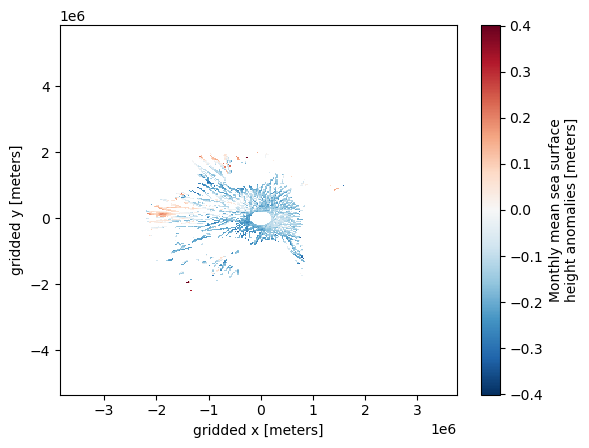

In [52]:
ds.mean_ssha.plot()

In [30]:
dt.groups

('/',
 '/ancillary_data',
 '/daily',
 '/monthly',
 '/orbit_info',
 '/quality_assessment',
 '/METADATA',
 '/ancillary_data/beam_selection',
 '/ancillary_data/refsurf_selection',
 '/daily/day14',
 '/daily/day15',
 '/daily/day16',
 '/daily/day17',
 '/daily/day18',
 '/daily/day19',
 '/daily/day20',
 '/daily/day21',
 '/daily/day22',
 '/daily/day23',
 '/daily/day24',
 '/daily/day25',
 '/daily/day26',
 '/daily/day27',
 '/daily/day28',
 '/daily/day29',
 '/daily/day30',
 '/daily/day31',
 '/METADATA/AcquisitionInformation',
 '/METADATA/DataQuality',
 '/METADATA/DatasetIdentification',
 '/METADATA/Extent',
 '/METADATA/Lineage',
 '/METADATA/ProcessStep',
 '/METADATA/ProductSpecificationDocument',
 '/METADATA/QADatasetIdentification',
 '/METADATA/SeriesIdentification',
 '/METADATA/AcquisitionInformation/lidar',
 '/METADATA/AcquisitionInformation/lidarDocument',
 '/METADATA/AcquisitionInformation/platform',
 '/METADATA/AcquisitionInformation/platformDocument',
 '/METADATA/DataQuality/CompletenessOmi

### Filter to the files you want

Once you see the files names, you can filter to the ones you want. using `granule_name`. For example `*.SNSP.*.4km.*` to get the seasonal (quarterly) values. `*` are wildcard values.

In [7]:
import point_collocation as pc
plan = pc.plan(
    df,
    data_source="earthaccess",
    source_kwargs={
        "short_name": short_name,
        "granule_name": "*.SNSP.*.4km.*"
    }
)

In [20]:
plan.summary()

Plan: 1 points → 1 unique granule(s)
  Points with 0 matches : 0
  Points with >1 matches: 0
  Variables  : []
  Time buffer: 0 days 00:00:00

First 1 point(s):
  [0] lat=30.0000, lon=-89.0000, time=2025-04-09 00:00:00: 1 match(es)
    → https://obdaac-tea.earthdatacloud.nasa.gov/ob-cumulus-prod-public/PACE_OCI.20250321_20250620.L3m.SNSP.AVW.V3_1.avw.4km.nc


In [7]:
plan.summary(n=0)

Plan: 100 points → 18 unique granule(s)
  Points with 0 matches : 0
  Points with >1 matches: 0
  Time buffer: 0 days 00:00:00


## Get matchups using that plan

In [7]:
%%time
res = pc.matchup(plan, geometry="grid", variables = ["avw"])

CPU times: user 2.5 s, sys: 353 ms, total: 2.86 s
Wall time: 8.33 s


In [8]:
res.head()

,lat,lon,time,pc_id,granule_id,granule_time,granule_lat,granule_lon,avw
0,27.3835,-82.7375,2024-06-13 12:00:00,0,https://obdaac-tea.earthdatacloud.nasa.gov/ob-...,2024-06-13 11:59:59+00:00,27.395832,-82.729164,NaN
1,27.1190,-82.7125,2024-06-14 12:00:00,1,https://obdaac-tea.earthdatacloud.nasa.gov/ob-...,2024-06-14 11:59:59+00:00,27.104164,-82.729164,NaN
2,26.9435,-82.8170,2024-06-14 12:00:00,2,https://obdaac-tea.earthdatacloud.nasa.gov/ob-...,2024-06-14 11:59:59+00:00,26.937498,-82.812500,NaN
3,26.6875,-82.8065,2024-06-14 12:00:00,3,https://obdaac-tea.earthdatacloud.nasa.gov/ob-...,2024-06-14 11:59:59+00:00,26.687498,-82.812500,NaN
4,26.6675,-82.6455,2024-06-14 12:00:00,4,https://obdaac-tea.earthdatacloud.nasa.gov/ob-...,2024-06-14 11:59:59+00:00,26.687498,-82.645828,NaN


## C2237824918-ORNL_CLOUD

collection_id = "C2237824918-ORNL_CLOUD"

* need to allow collection_id

In [54]:
import point_collocation as pc
plan = pc.plan(
    df[0:100],
    data_source="earthaccess",
    source_kwargs={
        "collection_id": "C2237824918-ORNL_CLOUD",
    }
)

ValueError: 'source_kwargs' must contain 'short_name' when data_source='earthaccess'.

## ECCO

In [2]:
df = df_points[
    (df_points["time"].dt.year == 1992) &
    (df_points["land"] == False)
]
df

,lat,lon,time,land
34,50.583735,161.482326,1992-12-09,False
46,7.795091,111.050051,1992-02-08,False
48,-8.825111,110.622506,1992-03-29,False
110,-55.679447,79.157835,1992-10-11,False
204,-58.200763,173.617904,1992-12-25,False
221,21.091280,119.381358,1992-11-28,False
243,-13.784118,56.182928,1992-09-06,False
397,40.189331,179.351254,1992-05-25,False
429,11.876228,139.250542,1992-12-11,False
465,-71.231272,178.142386,1992-10-01,False


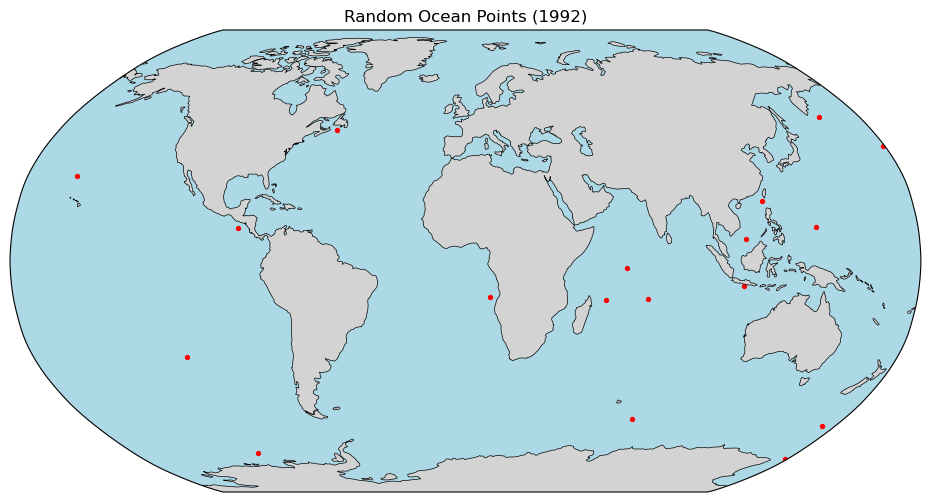

In [3]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# filter points
df = df_points[
    (df_points["time"].dt.year == 1992) &
    (~df_points["land"])
]

# create Robinson projection
proj = ccrs.Robinson()

fig = plt.figure(figsize=(12,6))
ax = plt.axes(projection=proj)

# add map features
ax.add_feature(cfeature.LAND, facecolor="lightgray")
ax.add_feature(cfeature.OCEAN, facecolor="lightblue")
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)

# plot points
ax.scatter(
    df["lon"],
    df["lat"],
    s=8,
    color="red",
    transform=ccrs.PlateCarree()
)

ax.set_global()
plt.title("Random Ocean Points (1992)")
plt.show()

In [4]:
import point_collocation as pc
short_name="ECCO_L4_SSH_05DEG_MONTHLY_V4R4"
plan = pc.plan(
    df,
    data_source="earthaccess",
    source_kwargs={
        "short_name": short_name,
    }
)
plan.summary()

Plan: 18 points → 10 unique granule(s)
  Points with 0 matches : 0
  Points with >1 matches: 2
  Time buffer: 0 days 00:00:00

First 5 point(s):
  [34] lat=50.5837, lon=161.4823, time=1992-12-09 00:00:00: 1 match(es)
    → https://archive.podaac.earthdata.nasa.gov/podaac-ops-cumulus-protected/ECCO_L4_SSH_05DEG_MONTHLY_V4R4/SEA_SURFACE_HEIGHT_mon_mean_1992-12_ECCO_V4r4_latlon_0p50deg.nc
  [46] lat=7.7951, lon=111.0501, time=1992-02-08 00:00:00: 1 match(es)
    → https://archive.podaac.earthdata.nasa.gov/podaac-ops-cumulus-protected/ECCO_L4_SSH_05DEG_MONTHLY_V4R4/SEA_SURFACE_HEIGHT_mon_mean_1992-02_ECCO_V4r4_latlon_0p50deg.nc
  [48] lat=-8.8251, lon=110.6225, time=1992-03-29 00:00:00: 1 match(es)
    → https://archive.podaac.earthdata.nasa.gov/podaac-ops-cumulus-protected/ECCO_L4_SSH_05DEG_MONTHLY_V4R4/SEA_SURFACE_HEIGHT_mon_mean_1992-03_ECCO_V4r4_latlon_0p50deg.nc
  [110] lat=-55.6794, lon=79.1578, time=1992-10-11 00:00:00: 1 match(es)
    → https://archive.podaac.earthdata.nasa.gov/pod

In [14]:
plan.show_variables(geometry="grid")

geometry     : 'grid'
open_method  : 'dataset'
Dimensions : {'time': 1, 'latitude': 360, 'longitude': 720, 'nv': 2}
Variables  : ['SSH', 'SSHIBC', 'SSHNOIBC']

Geolocation: ('longitude', 'latitude') — lon dims=('longitude',), lat dims=('latitude',)


In [5]:
%%time
res = pc.matchup(plan, geometry="grid", variables = ["SSH"])

CPU times: user 2.07 s, sys: 172 ms, total: 2.24 s
Wall time: 4.73 s


In [8]:
res

,lat,lon,time,land,pc_id,granule_id,granule_time,granule_lat,granule_lon,SSH
0,45.724907,-56.813953,1992-01-05,False,635,https://archive.podaac.earthdata.nasa.gov/poda...,1992-01-16 18:00:00+00:00,45.75,-56.75,NaN
1,-12.612122,9.857356,1992-02-01,False,683,https://archive.podaac.earthdata.nasa.gov/poda...,1992-01-16 18:00:00+00:00,-12.75,9.75,NaN
2,29.609056,-159.535919,1992-01-07,False,750,https://archive.podaac.earthdata.nasa.gov/poda...,1992-01-16 18:00:00+00:00,29.75,-159.75,NaN
3,7.795091,111.050051,1992-02-08,False,46,https://archive.podaac.earthdata.nasa.gov/poda...,1992-02-15 12:00:00+00:00,7.75,111.25,NaN
4,-12.612122,9.857356,1992-02-01,False,683,https://archive.podaac.earthdata.nasa.gov/poda...,1992-02-15 12:00:00+00:00,-12.75,9.75,NaN
5,-8.825111,110.622506,1992-03-29,False,48,https://archive.podaac.earthdata.nasa.gov/poda...,1992-03-16 12:00:00+00:00,-8.75,110.75,NaN
6,-68.656155,-112.526253,1992-04-02,False,837,https://archive.podaac.earthdata.nasa.gov/poda...,1992-04-16 00:00:00+00:00,-68.75,-112.75,NaN
7,40.189331,179.351254,1992-05-25,False,397,https://archive.podaac.earthdata.nasa.gov/poda...,1992-05-16 12:00:00+00:00,40.25,179.25,NaN
8,-33.571769,-116.090272,1992-05-04,False,950,https://archive.podaac.earthdata.nasa.gov/poda...,1992-05-16 12:00:00+00:00,-33.75,-116.25,NaN
9,11.611758,-90.341076,1992-06-28,False,815,https://archive.podaac.earthdata.nasa.gov/poda...,1992-06-16 00:00:00+00:00,11.75,-90.25,NaN


In [6]:
import earthaccess
results = earthaccess.search_data(
    short_name=short_name,
    temporal = ("1992-12-01", "1992-12-31")
)
print(len(results))
f = earthaccess.open(results[0:2])

2


QUEUEING TASKS | :   0%|          | 0/2 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/2 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/2 [00:00<?, ?it/s]

In [7]:
import xarray as xr
ds = xr.open_dataset(f[1])
ds

<xarray.Dataset> Size: 3MB
Dimensions:         (time: 1, latitude: 360, longitude: 720, nv: 2)
Coordinates:
  * time            (time) datetime64[ns] 8B 1992-12-16T12:00:00
  * latitude        (latitude) float32 1kB -89.75 -89.25 -88.75 ... 89.25 89.75
  * longitude       (longitude) float32 3kB -179.8 -179.2 -178.8 ... 179.2 179.8
    time_bnds       (time, nv) datetime64[ns] 16B ...
    latitude_bnds   (latitude, nv) float32 3kB ...
    longitude_bnds  (longitude, nv) float32 6kB ...
Dimensions without coordinates: nv
Data variables:
    SSH             (time, latitude, longitude) float32 1MB ...
    SSHIBC          (time, latitude, longitude) float32 1MB ...
    SSHNOIBC        (time, latitude, longitude) float32 1MB ...
Attributes: (12/57)
    acknowledgement:              This research was carried out by the Jet Pr...
    author:                       Ian Fenty and Ou Wang
    cdm_data_type:                Grid
    comment:                      Fields provided on a regular lat-lon grid. ...
    Conventions:                  CF-1.8, ACDD-1.3
    coordinates_comment:          Note: the global 'coordinates' attribute de...
    ...                           ...
    time_coverage_duration:       P1M
    time_coverage_end:            1993-01-01T00:00:00
    time_coverage_resolution:     P1M
    time_coverage_start:          1992-12-01T00:00:00
    title:                        ECCO Sea Surface Height - Monthly Mean 0.5 ...
    uuid:                         09105c40-4158-11eb-8311-0cc47a3f5153

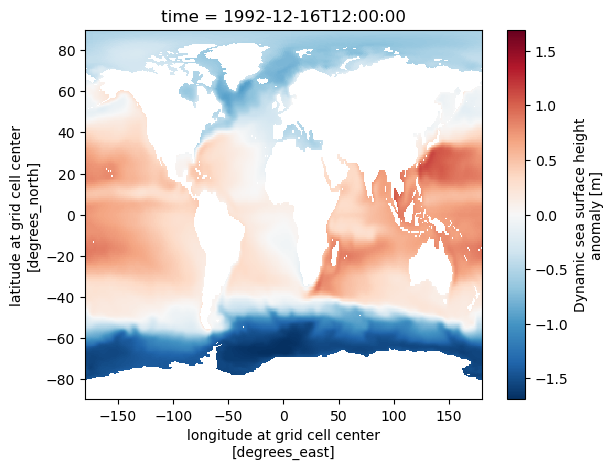

In [22]:
ds.SSH.plot()

In [28]:
ds.SSH.sel(latitude=df.lat.iloc[0], longitude=df.lon.iloc[0], method="nearest").values

array([0.10287101], dtype=float32)

In [26]:
df.lon.iloc[0]

np.float64(-107.62675250689612)